In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from scripts.tracking.runs import query_runs, list_runs

RUNS = [
    ('finance_agent', 'ambrosial', 'mushroom',    'finance_agent'),
    ('claude', 'notorious', 'robin',     'claude_opus47'),
    ('claude', 'classic',   'wolf',      'claude_haiku45'),
    ('openai', 'keen',      'rhino',     'openai'),
]

frames = []
for provider, inf_slug, eval_slug, label in RUNS:
    df = query_runs(inf_run_id=inf_slug, eval_run_id=eval_slug)
    df['provider'] = label
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
print(raw.shape, list(raw.columns))

(1130, 29) ['run_db_id', 'inf_run_id', 'eval_run_id', 'timestamp', 'provider', 'model', 'judge', 'inference_config_hash', 'eval_config_hash', 'inference_file', 'eval_file', 'question', 'plugin', 'segment', 'tool_call_count', 'successful_tool_calls', 'inference_time_secs', 'answer_length', 'answer', 'tag_reasoning', 'overall_score', 'clarity_score', 'depth_score', 'groundedness_score', 'relevance_score', 'structure_score', 'citations_score', 'recency_score', 'accuracy_score']


In [2]:
# Melt score columns into (metric, score) rows
score_cols = [c for c in raw.columns if c.endswith('_score') and c != 'overall_score']
id_cols = ['provider', 'question', 'plugin', 'segment', 'inference_time_secs']

long = raw[id_cols + score_cols].melt(
    id_vars=id_cols,
    value_vars=score_cols,
    var_name='metric',
    value_name='score',
)
long['metric'] = long['metric'].str.removesuffix('_score')
long = long.dropna(subset=['score'])  # drop (plugin, metric) combos that don't exist


In [3]:
# # select rows with metric scores of accuracy, depth, and structure
# canonical_metrics = ['accuracy_score', 'depth_score', 'structure_score']
# raw = raw.drop(columns=[c for c in raw.columns if c.endswith('_score') and c not in canonical_metrics])

Computing weighted scores and bootstrap CIs...
Running LMM significance tests (may take ~30 s)...
Done.


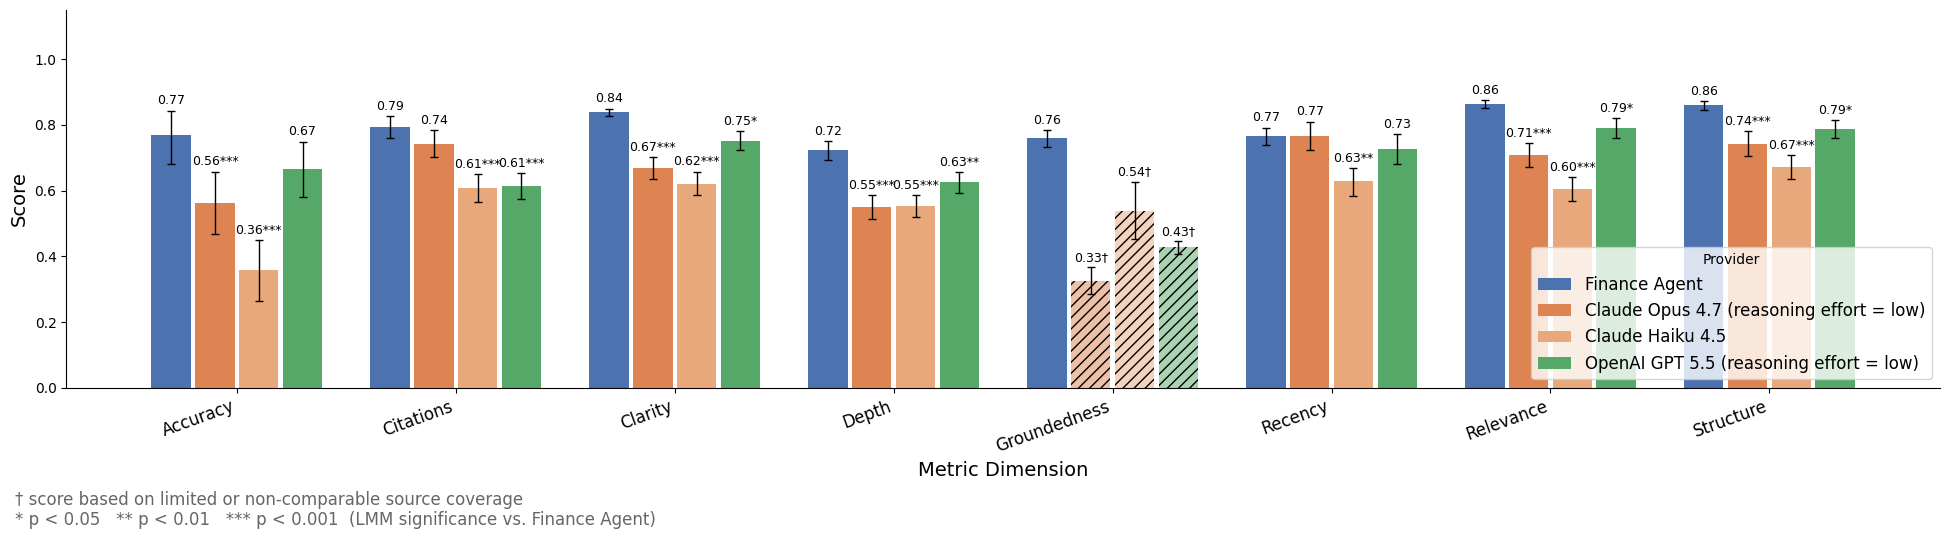

In [4]:
import numpy as np
import warnings
from scipy.stats import norm as scipy_norm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configuration ─────────────────────────────────────────────────────────────
timeout = 60
timeout_business_brief = 300
hatch_bars = {('openai', 'groundedness'), ('claude_opus47', 'groundedness'), ('claude_haiku45', 'groundedness')}
_PALETTE = {
    'finance_agent':        '#4C72B0',
    'claude_opus47': '#DD8452',
    'claude_haiku45':'#E8A87C',
    'openai':        '#55A868',
}
PROVIDER_DISPLAY = {
    'finance_agent':        'Finance Agent',
    'claude_opus47': 'Claude Opus 4.7 (reasoning effort = low)',
    'claude_haiku45':'Claude Haiku 4.5',
    'openai':        'OpenAI GPT 5.5 (reasoning effort = low)',
}

raw_w = raw.copy()

score_cols_w = [c for c in raw_w.columns if c.endswith('_score') and c != 'overall_score']
bb_mask_w = raw_w['plugin'] == 'business_brief'
timed_out_w = (
    raw_w['inference_time_secs'].notna() &
    (
        (bb_mask_w  & (raw_w['inference_time_secs'] >= timeout_business_brief)) |
        (~bb_mask_w & (raw_w['inference_time_secs'] >= timeout))
    )
)
for _col in score_cols_w:
    raw_w.loc[timed_out_w & raw_w[_col].notna(), _col] = 0.0

# ── Pool segment-specific metrics (e.g. peers_depth_score → depth_score) ──────
def _pool(df):
    sc = [c for c in df.columns if c.endswith('_score') and c != 'overall_score']
    explicit = {c[:-6] for c in sc if '_' not in c[:-6]}
    suffix_counts = {}
    for c in sc:
        n = c[:-6]
        if '_' in n:
            s = n.rsplit('_', 1)[1]
            suffix_counts[s] = suffix_counts.get(s, 0) + 1
    bases = explicit | {s for s, cnt in suffix_counts.items() if cnt >= 2}
    col_to_base = {}
    for c in sc:
        n = c[:-6]
        suf = n.rsplit('_', 1)[1] if '_' in n else None
        col_to_base[c] = suf if suf in bases else n
    base_to_cols = {}
    for c, b in col_to_base.items():
        base_to_cols.setdefault(b, []).append(c)
    out = df.copy()
    for b, cols in base_to_cols.items():
        pooled = f'{b}_score'
        if not (len(cols) == 1 and cols[0] == pooled):
            out[pooled] = df[cols].mean(axis=1)
        for c in cols:
            if c != pooled and c in out.columns:
                out.drop(columns=[c], inplace=True)
    return out

provider_dfs = {p: _pool(raw_w[raw_w['provider'] == p].copy()) for p in raw_w['provider'].unique()}
providers = [r[3] for r in RUNS]  # use label (4th element), preserving RUNS order

all_sc = set()
for _df in provider_dfs.values():
    all_sc.update(c for c in _df.columns if c.endswith('_score') and c != 'overall_score')
canonical_metrics = sorted(c[:-6] for c in all_sc if '_' not in c[:-6])

# ── Weighted scores (mean of plugin means) ────────────────────────────────────
def _plugin_means(df, metrics):
    out = {}
    for pl in sorted(df['plugin'].dropna().unique()):
        pdata = df[df['plugin'] == pl]
        scores = {m: float(pdata[f'{m}_score'].dropna().mean())
                  for m in metrics
                  if f'{m}_score' in pdata.columns and pdata[f'{m}_score'].dropna().size > 0}
        if scores:
            out[pl] = scores
    return out

def _weighted(ps, metrics):
    return {m: float(np.mean([ps[p][m] for p in ps if m in ps[p]]))
            for m in metrics if any(m in ps[p] for p in ps)}

# ── Bootstrap 95% CI ──────────────────────────────────────────────────────────
def _bci(df, metric, n_boot=1000, seed=42):
    col = f'{metric}_score'
    if col not in df.columns:
        return (0.0, 0.0)
    sub = df[['plugin', col]].dropna()
    if sub.empty:
        return (0.0, 0.0)
    rng = np.random.default_rng(seed)
    scores, labels = sub[col].to_numpy(), sub['plugin'].to_numpy()
    uplabels = np.unique(labels)
    all_idx = rng.integers(0, len(scores), size=(n_boot, len(scores)))
    boot = np.empty(n_boot)
    for i in range(n_boot):
        idx = all_idx[i]
        s, p = scores[idx], labels[idx]
        pmeans = [s[p == pl].mean() for pl in uplabels if (p == pl).any()]
        boot[i] = np.mean(pmeans) if pmeans else 0.0
    return float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

# ── LMM significance tests ────────────────────────────────────────────────────
def _contrast(pnames, other, nrp, target=None):
    pidx = {n: i for i, n in enumerate(pnames)}
    c = np.zeros(len(pnames))
    k = len(nrp) + 1
    mk = f'C(provider)[T.{other}]'
    if mk in pidx:
        c[pidx[mk]] = 1.0
    for pl in (nrp if target is None else ([target] if target in nrp else [])):
        ik = f'C(provider)[T.{other}]:C(plugin)[T.{pl}]'
        if ik in pidx:
            c[pidx[ik]] = (1.0 / k if target is None else 1.0)
    return c

def _lmm(combined, metric, ref, all_providers, ref_plugin):
    col = f'{metric}_score'
    if col not in combined.columns:
        return {}
    present = [p for p in all_providers if p in combined['provider'].unique()]
    non_ref = [p for p in present if p != ref]
    if not non_ref:
        return {}
    sub = combined[combined['provider'].isin(present)][['question', 'provider', 'plugin', col]].dropna().copy()
    if any((sub['provider'] == p).sum() < 5 for p in present):
        return {}
    all_pl = sorted(sub['plugin'].dropna().unique())
    ref_pl = ref_plugin if ref_plugin in all_pl else all_pl[0]
    nrp = [p for p in all_pl if p != ref_pl]
    sub['provider'] = pd.Categorical(sub['provider'], categories=[ref] + [p for p in present if p != ref])
    sub['plugin']   = pd.Categorical(sub['plugin'],   categories=[ref_pl] + nrp)
    formula = (f'{col} ~ C(provider) * C(plugin)' if len(all_pl) >= 2 else f'{col} ~ C(provider)')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            fit = smf.mixedlm(formula, sub, groups=sub['question']).fit(reml=False)
            if not getattr(fit, 'converged', True):
                return {}
        except Exception:
            return {}
    pnames = list(fit.params.index)
    params, cov_arr = fit.params.values, np.array(fit.cov_params())
    result = {}
    for other in non_ref:
        c = _contrast(pnames, other, nrp if len(all_pl) >= 2 else [])
        beta = float(c @ params)
        se   = float(np.sqrt(max(float(c @ cov_arr @ c), 0.0)))
        z    = beta / se if se > 1e-10 else 0.0
        result[f'{ref}_vs_{other}'] = {'pvalue': float(2.0 * scipy_norm.sf(abs(z))), 'lmm_beta': beta}
    return result

def _compute_sig(provider_dfs, providers, ref, metrics):
    combined = pd.concat([df.assign(provider=p) for p, df in provider_dfs.items()], ignore_index=True)
    all_pl   = sorted(combined['plugin'].dropna().unique())
    ref_pl   = 'erp_qa' if 'erp_qa' in all_pl else all_pl[0]
    ref_w    = _weighted(_plugin_means(provider_dfs[ref], metrics), metrics)
    oth_w    = {p: _weighted(_plugin_means(provider_dfs[p], metrics), metrics)
                for p in providers if p != ref and p in provider_dfs}
    sig = {}
    for m in metrics:
        lmm = _lmm(combined, m, ref, [ref] + list(oth_w), ref_pl)
        sig[m] = {}
        for other in oth_w:
            key = f'{ref}_vs_{other}'
            res = lmm.get(key)
            if res:
                res = res.copy()
                res['direction'] = 1 if ref_w.get(m, 0) >= oth_w[other].get(m, 0) else -1
            sig[m][key] = res
    return sig

def _stars(pval):
    if pval is None or pval >= 0.05:
        return ''
    return '***' if pval < 0.001 else '**' if pval < 0.01 else '*'

# ── Compute ───────────────────────────────────────────────────────────────────
print("Computing weighted scores and bootstrap CIs...")
all_ps = {p: _plugin_means(df, canonical_metrics) for p, df in provider_dfs.items()}
all_w  = {p: _weighted(all_ps[p], canonical_metrics) for p in provider_dfs}
all_ci = {p: {m: _bci(df, m) for m in canonical_metrics} for p, df in provider_dfs.items()}

print("Running LMM significance tests (may take ~30 s)...")
reference = providers[0]
sig = _compute_sig(provider_dfs, providers, reference, canonical_metrics)
print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
active = [p for p in providers if p in provider_dfs]
n_m, n_p = len(canonical_metrics), len(active)
bar_w = 0.8 / n_p
x = np.arange(n_m)

fig, ax = plt.subplots(figsize=(max(8, n_m * n_p * 0.55 + 2), 5))

for pi, p in enumerate(active):
    offsets = x + (pi - n_p / 2 + 0.5) * bar_w
    heights  = [all_w[p].get(m, 0.0) for m in canonical_metrics]
    ci_lo    = [all_w[p].get(m, 0.0) - all_ci[p][m][0] for m in canonical_metrics]
    ci_hi    = [all_ci[p][m][1] - all_w[p].get(m, 0.0) for m in canonical_metrics]
    bars = ax.bar(
        offsets, heights,
        width=bar_w * 0.9,
        color=_PALETTE.get(p, '#999999'),
        label=PROVIDER_DISPLAY.get(p, p),
        yerr=[ci_lo, ci_hi], capsize=3,
        error_kw={'elinewidth': 1},
    )
    for mi, (bar, h, hi) in enumerate(zip(bars, heights, ci_hi)):
        m = canonical_metrics[mi]
        is_h = bool(hatch_bars and (p, m) in hatch_bars)
        if is_h:
            bar.set_hatch('///')
            bar.set_alpha(0.5)
        if h <= 0:
            continue
        stars = ''
        if p != reference:
            entry = sig.get(m, {}).get(f'{reference}_vs_{p}')
            stars = _stars(entry['pvalue'] if entry else None)
        ax.text(bar.get_x() + bar.get_width() / 2, h + hi + 0.01,
                f'{h:.2f}{stars}{"†" if is_h else ""}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').capitalize() for m in canonical_metrics], rotation=20, ha='right', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=14)
ax.set_xlabel('Metric Dimension', fontsize=14)
ax.legend(title='Provider', fontsize=12, loc='lower right')
if hatch_bars:
    fig.text(0.01, -0.02, '† score based on limited or non-comparable source coverage',
             fontsize=12, color='#666666', ha='left')
fig.text(0.01, -0.06 if hatch_bars else -0.02,
         '* p < 0.05   ** p < 0.01   *** p < 0.001  (LMM significance vs. Finance Agent)',
         fontsize=12, color='#666666', ha='left')
sns.despine()
plt.tight_layout()
plt.show()

In [5]:
fig.savefig('../result.png', dpi=150, bbox_inches='tight')